In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('CreditDataClean.csv')
print(df.head())

   person_age  person_income person_home_ownership  person_emp_length  \
0          21           9600                   OWN                  5   
1          25           9600              MORTGAGE                  1   
2          23          65500                  RENT                  4   
3          24          54400                  RENT                  8   
4          21           9900                   OWN                  2   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0   EDUCATION          B       1000          11.14            0   
1     MEDICAL          C       5500          12.87            1   
2     MEDICAL          C      35000          15.23            1   
3     MEDICAL          C      35000          14.27            1   
4     VENTURE          A       2500           7.14            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.10                         N                           2  


**Single Variable Visualizations**

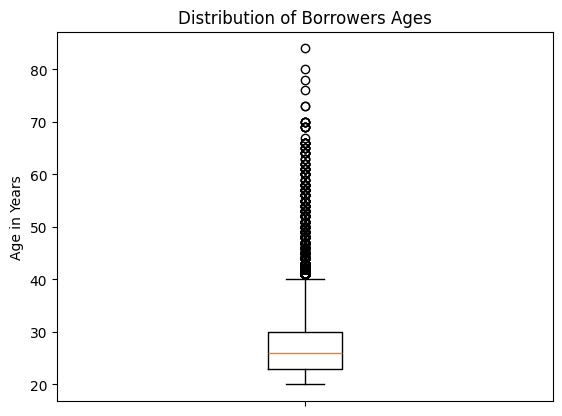

In [3]:
plt.boxplot(df['person_age'])
plt.ylabel('Age in Years')
plt.title('Distribution of Borrowers Ages')
plt.xticks([1], [''])
plt.show()

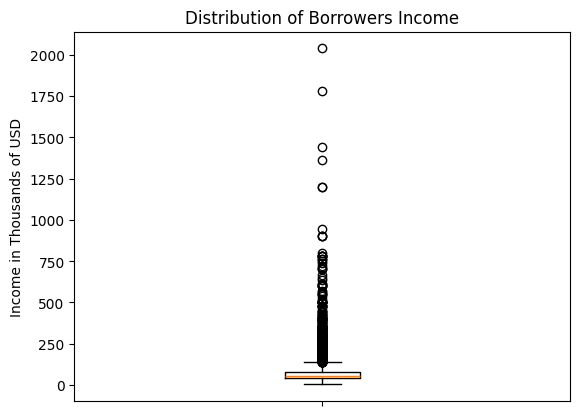

In [4]:
plt.boxplot(df['person_income']/1000)
plt.title('Distribution of Borrowers Income')
plt.ylabel('Income in Thousands of USD')
plt.xticks([1], [''])
plt.show()

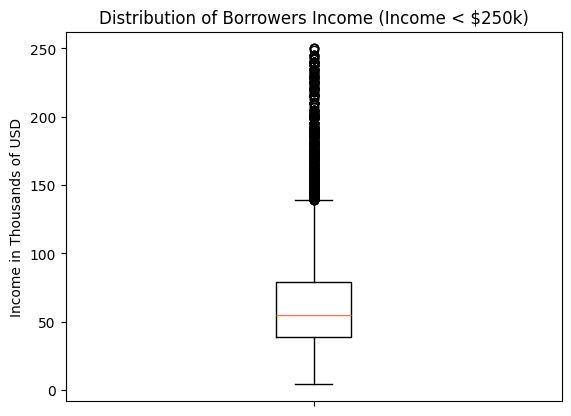

In [5]:
plt.boxplot(df[df['person_income']/1000 < 250]['person_income']/1000)
plt.title('Distribution of Borrowers Income (Income < $250k)')
plt.ylabel('Income in Thousands of USD')
plt.xticks([1], [''])
plt.show()

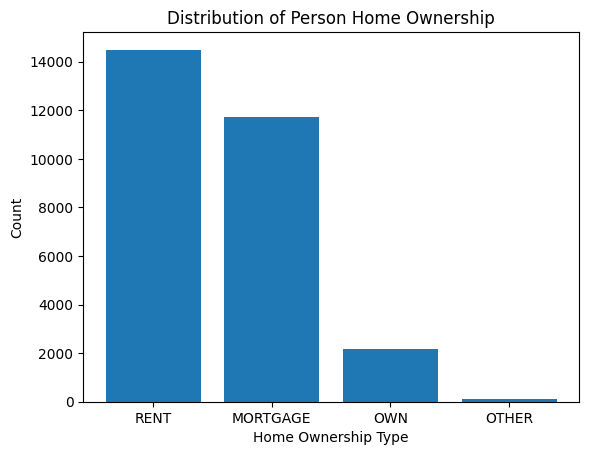

In [6]:
home_ownership_counts = df['person_home_ownership'].value_counts()

plt.bar(home_ownership_counts.index, home_ownership_counts.values)
plt.xlabel('Home Ownership Type')
plt.ylabel('Count')
plt.title('Distribution of Person Home Ownership')
plt.show()

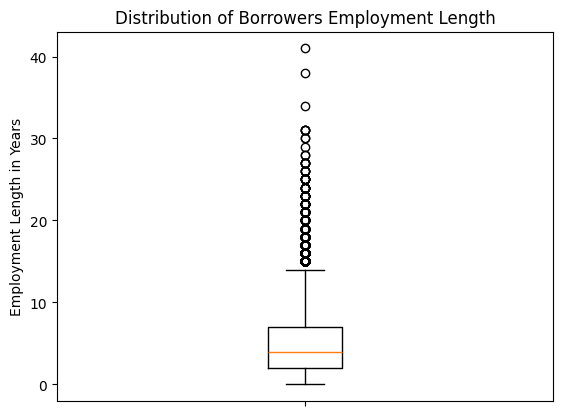

In [7]:
plt.boxplot(df['person_emp_length'])
plt.title('Distribution of Borrowers Employment Length')
plt.ylabel('Employment Length in Years')
plt.xticks([1], [''])
plt.show()

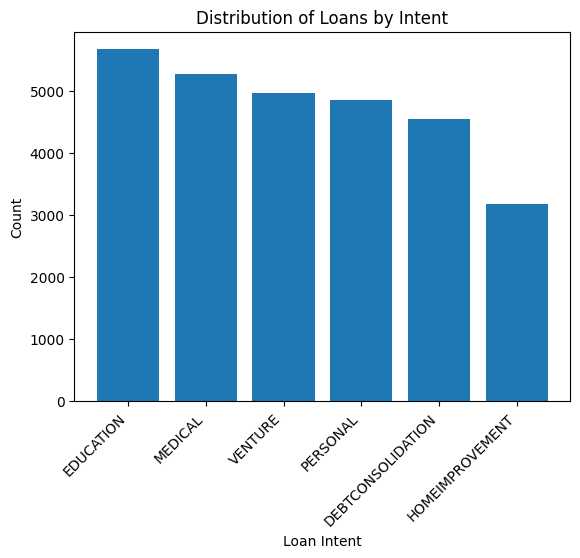

In [8]:
home_ownership_counts = df['loan_intent'].value_counts()

plt.bar(home_ownership_counts.index, home_ownership_counts.values)
plt.xlabel('Loan Intent')
plt.ylabel('Count')
plt.title('Distribution of Loans by Intent')
plt.xticks(rotation=45, ha='right')
plt.show()

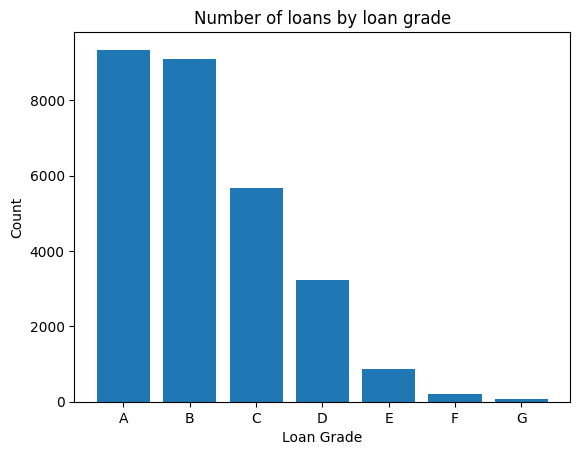

In [9]:
home_ownership_counts = df['loan_grade'].value_counts()

plt.bar(home_ownership_counts.index, home_ownership_counts.values)
plt.xlabel('Loan Grade')
plt.ylabel('Count')
plt.title('Number of loans by loan grade')
plt.show()

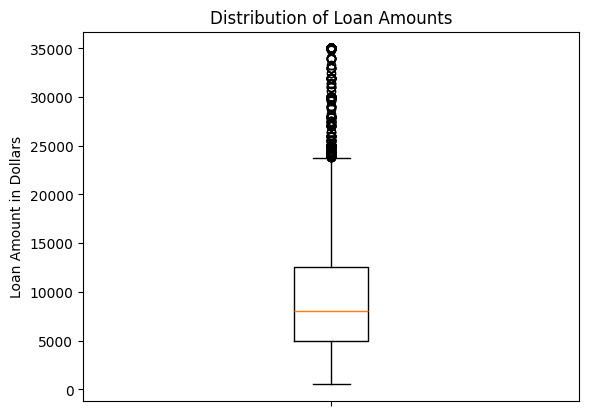

In [10]:
plt.boxplot(df['loan_amnt'])
plt.title('Distribution of Loan Amounts')
plt.ylabel('Loan Amount in Dollars')
plt.xticks([1], [''])
plt.show()

In [11]:
print(df['loan_amnt'].min())
print(df['loan_amnt'].max())

500
35000


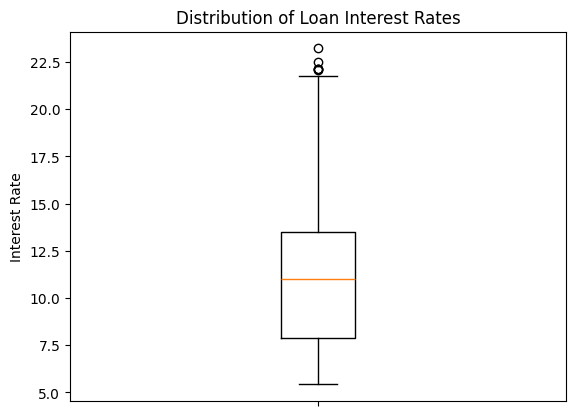

In [12]:
plt.boxplot(df['loan_int_rate'])
plt.title('Distribution of Loan Interest Rates')
plt.ylabel('Interest Rate')
plt.xticks([1], [''])
plt.show()

In [13]:
df['loan_int_rate'].describe()

,loan_int_rate
count,28495.000000
mean,11.045220
std,3.230786
min,5.420000
25%,7.900000
50%,10.990000
75%,13.480000
max,23.220000


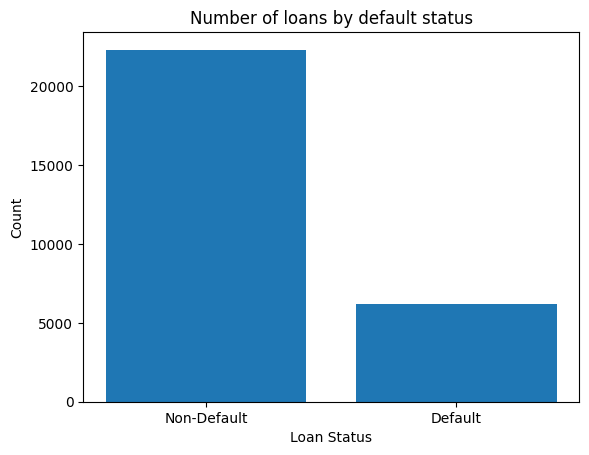

In [14]:
home_ownership_counts = df['loan_status'].value_counts()

plt.bar(home_ownership_counts.index, home_ownership_counts.values)
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.title('Number of loans by default status')
plt.xticks([0, 1], ['Non-Default', 'Default'])
plt.show()

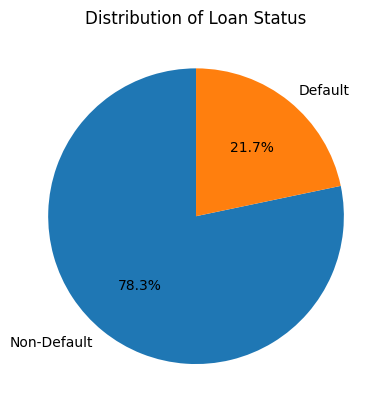

In [15]:
df['loan_status'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90, labels=['Non-Default', 'Default'])
plt.title('Distribution of Loan Status')
plt.ylabel('')
plt.show()

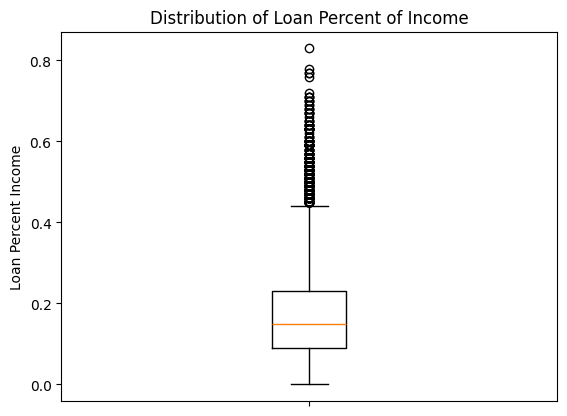

In [16]:
plt.boxplot(df['loan_percent_income'])
plt.title('Distribution of Loan Percent of Income')
plt.ylabel('Loan Percent Income')
plt.xticks([1], [''])
plt.show()

In [17]:
print(df['loan_percent_income'].mean().round(2))
print(df['loan_percent_income'].median())
print(df['loan_percent_income'].max())
print(df['loan_percent_income'].quantile(.99))

0.17
0.15
0.83
0.5


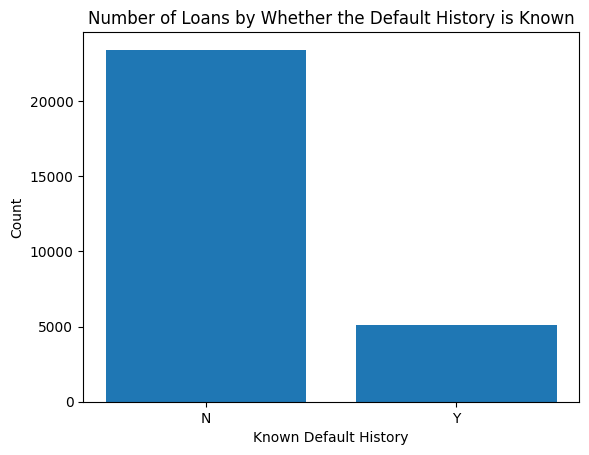

In [18]:
home_ownership_counts = df['cb_person_default_on_file'].value_counts()

plt.bar(home_ownership_counts.index, home_ownership_counts.values)
plt.xlabel('Known Default History')
plt.ylabel('Count')
plt.title('Number of Loans by Whether the Default History is Known')
plt.show()

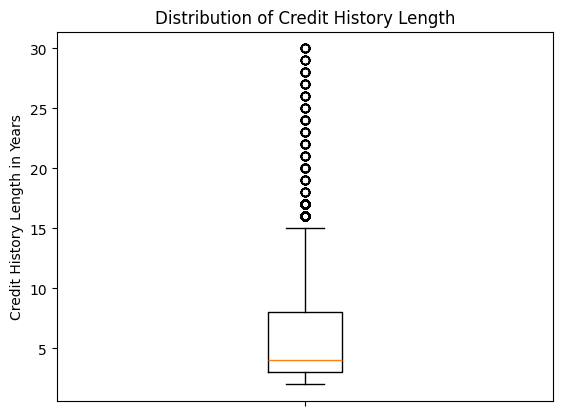

In [19]:
plt.boxplot(df['cb_person_cred_hist_length'])
plt.title('Distribution of Credit History Length')
plt.ylabel('Credit History Length in Years')
plt.xticks([1], [''])
plt.show()

**Multivariable Visualizations**

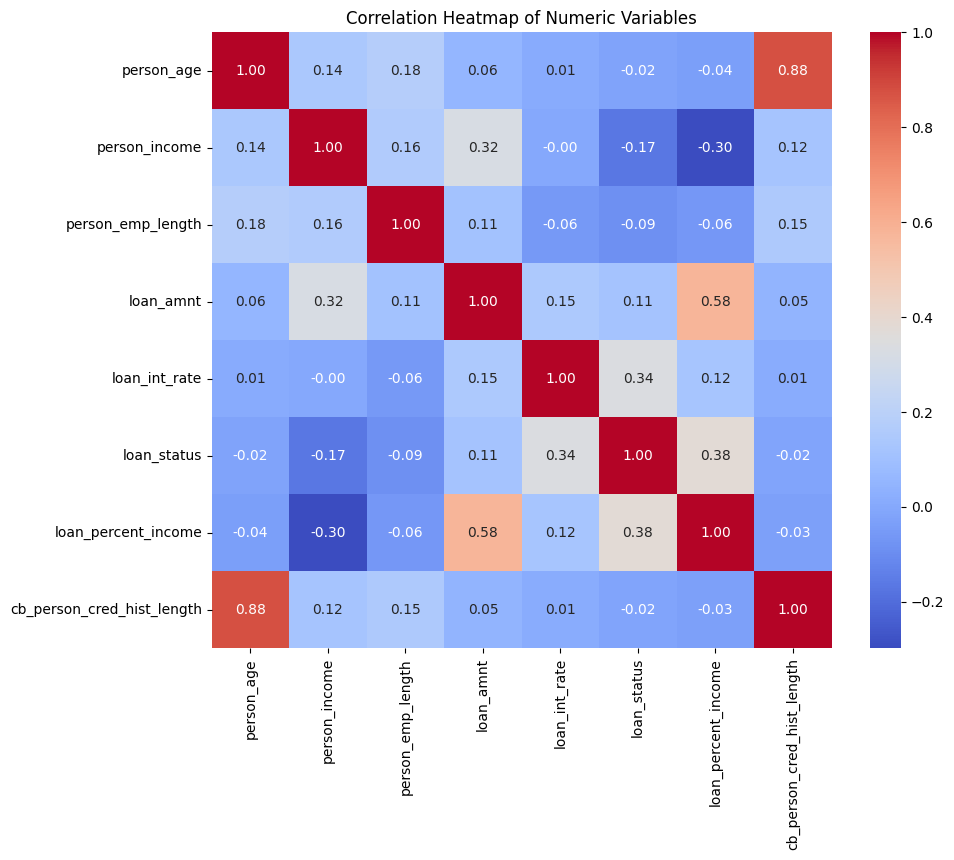

In [20]:
numeric_df = df.select_dtypes(include=np.number)
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numeric Variables')
plt.show()

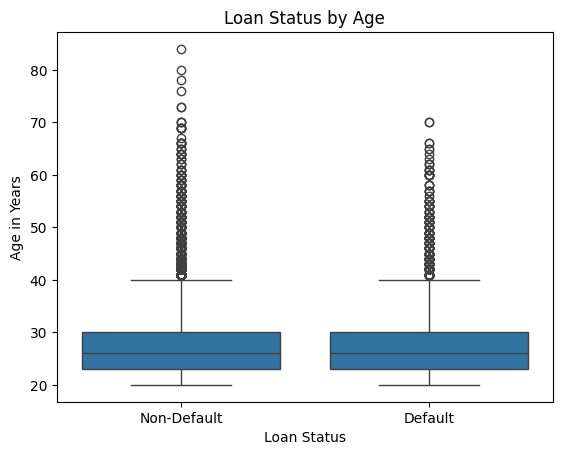

In [21]:
sns.boxplot(x='loan_status', y='person_age', data=df)

plt.title('Loan Status by Age')

plt.ylabel('Age in Years')
plt.xlabel('Loan Status')

plt.xticks([0, 1], ['Non-Default', 'Default'])

plt.show()

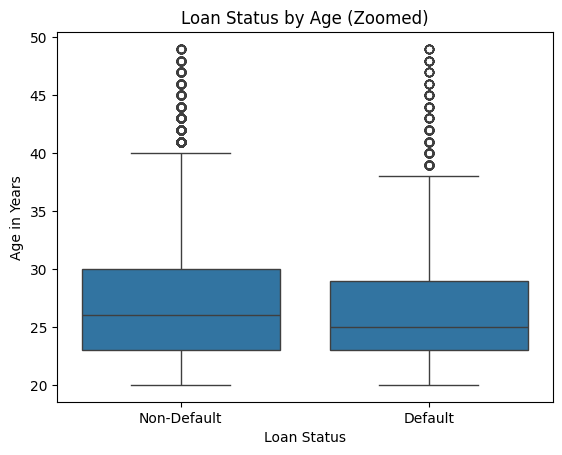

In [22]:
dfagezoom = df[df['person_age'] < 50]
sns.boxplot(x='loan_status', y='person_age', data=dfagezoom)

plt.title('Loan Status by Age (Zoomed)')

plt.ylabel('Age in Years')
plt.xlabel('Loan Status')

plt.xticks([0, 1], ['Non-Default', 'Default'])

plt.show()

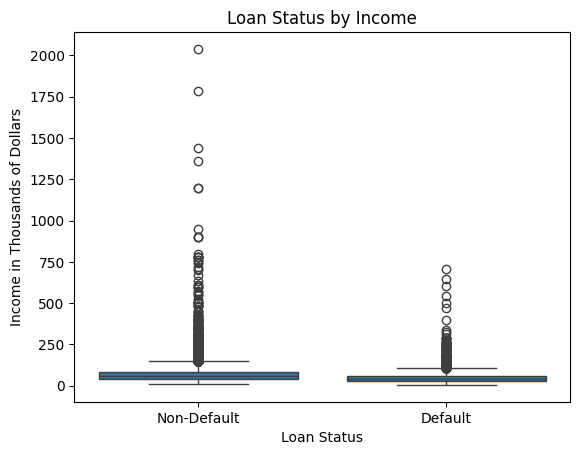

In [23]:
sns.boxplot(x='loan_status', y=df['person_income']/1000, data=df)

plt.title('Loan Status by Income')

plt.ylabel('Income in Thousands of Dollars')
plt.xlabel('Loan Status')

plt.xticks([0, 1], ['Non-Default', 'Default'])

plt.show()

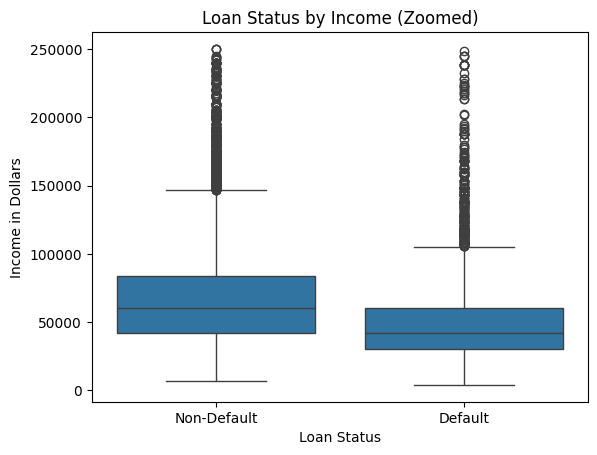

In [24]:
dfincmzoom = df[df['person_income'] < 250000]
sns.boxplot(x='loan_status', y='person_income', data=dfincmzoom)

plt.title('Loan Status by Income (Zoomed)')

plt.ylabel('Income in Dollars')
plt.xlabel('Loan Status')

plt.xticks([0, 1], ['Non-Default', 'Default'])

plt.show()

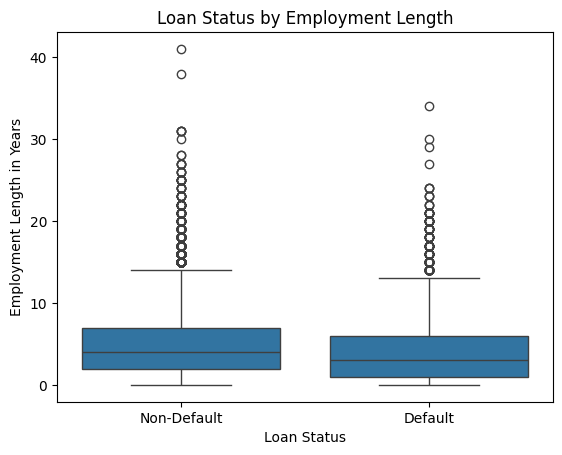

In [25]:
sns.boxplot(x='loan_status', y='person_emp_length', data=df)

plt.title('Loan Status by Employment Length')

plt.ylabel('Employment Length in Years')
plt.xlabel('Loan Status')

plt.xticks([0, 1], ['Non-Default', 'Default'])

plt.show()

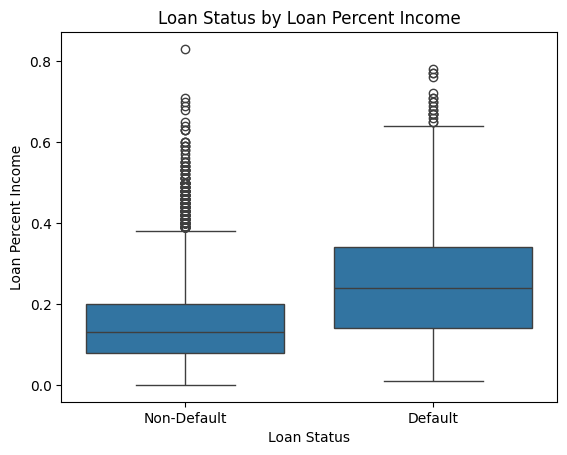

In [26]:
sns.boxplot(x='loan_status', y='loan_percent_income', data=df)

plt.title('Loan Status by Loan Percent Income')

plt.ylabel('Loan Percent Income')
plt.xlabel('Loan Status')

plt.xticks([0, 1], ['Non-Default', 'Default'])

plt.show()

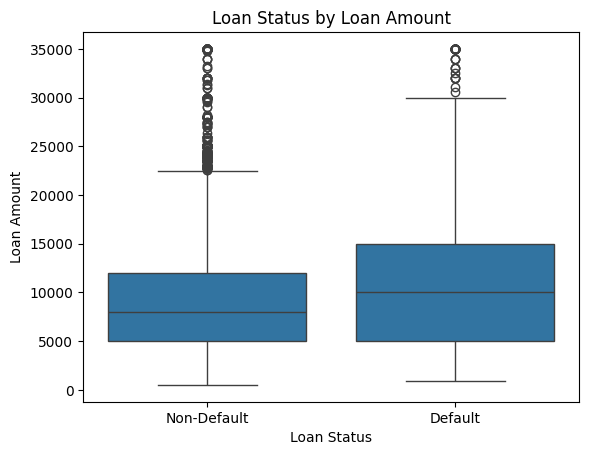

In [27]:
sns.boxplot(x='loan_status', y='loan_amnt', data=df)

plt.title('Loan Status by Loan Amount')

plt.ylabel('Loan Amount')
plt.xlabel('Loan Status')

plt.xticks([0, 1], ['Non-Default', 'Default'])

plt.show()

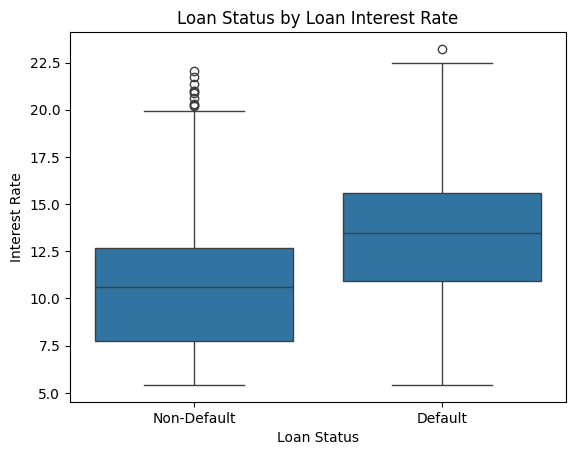

In [28]:
sns.boxplot(x='loan_status', y='loan_int_rate', data=df)

plt.title('Loan Status by Loan Interest Rate')

plt.ylabel('Interest Rate')
plt.xlabel('Loan Status')

plt.xticks([0, 1], ['Non-Default', 'Default'])

plt.show()

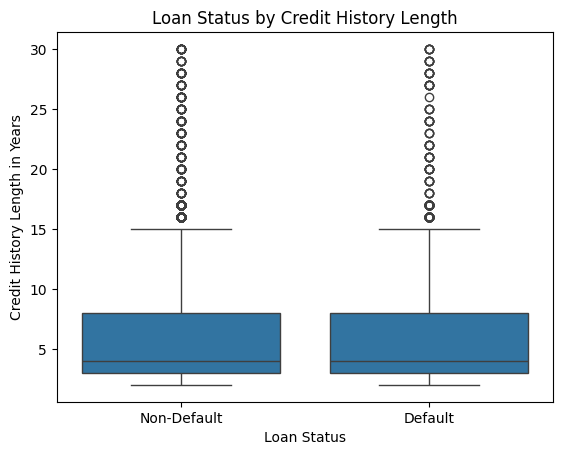

In [29]:
sns.boxplot(x='loan_status', y='cb_person_cred_hist_length', data=df)

plt.title('Loan Status by Credit History Length')

plt.ylabel('Credit History Length in Years')
plt.xlabel('Loan Status')

plt.xticks([0, 1], ['Non-Default', 'Default'])

plt.show()

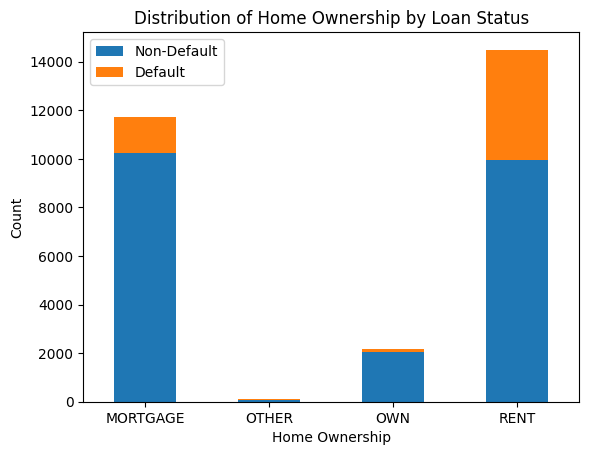

In [30]:
loan_status_home_ownership_counts = df.groupby('person_home_ownership')['loan_status'].value_counts().unstack()

loan_status_home_ownership_counts.plot(kind='bar', stacked=True)
plt.xlabel('Home Ownership')
plt.ylabel('Count')
plt.legend(['Non-Default', 'Default'])
plt.title('Distribution of Home Ownership by Loan Status')
plt.xticks(rotation=0)
plt.show()

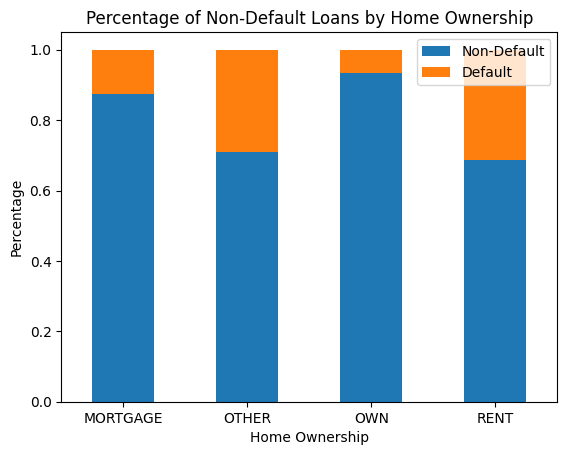

In [31]:
loan_status_home_ownership_counts = df.groupby('person_home_ownership')['loan_status'].value_counts().unstack()
loan_status_home_ownership_percentages = loan_status_home_ownership_counts.divide(loan_status_home_ownership_counts.sum(axis=1), axis=0)

loan_status_home_ownership_percentages.plot(kind='bar', stacked=True)
plt.xlabel('Home Ownership')
plt.legend(['Non-Default', 'Default'])
plt.ylabel('Percentage')
plt.title('Percentage of Non-Default Loans by Home Ownership')
plt.xticks(rotation=0)
plt.show()

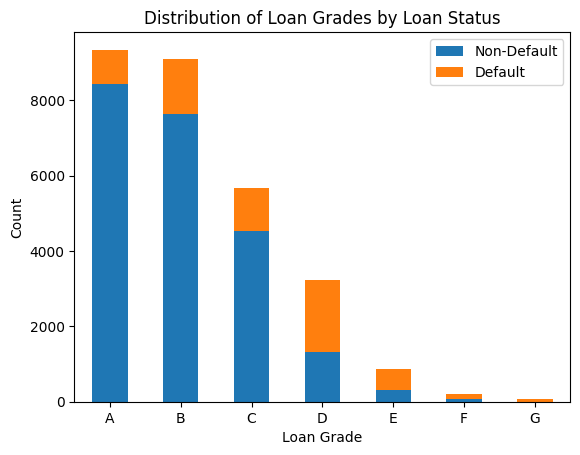

In [32]:
loan_status_loan_grade_counts = df.groupby('loan_grade')['loan_status'].value_counts().unstack()

loan_status_loan_grade_counts.plot(kind='bar', stacked=True)
plt.xlabel('Loan Grade')
plt.legend(['Non-Default', 'Default'])
plt.ylabel('Count')
plt.title('Distribution of Loan Grades by Loan Status')
plt.xticks(rotation=0)
plt.show()

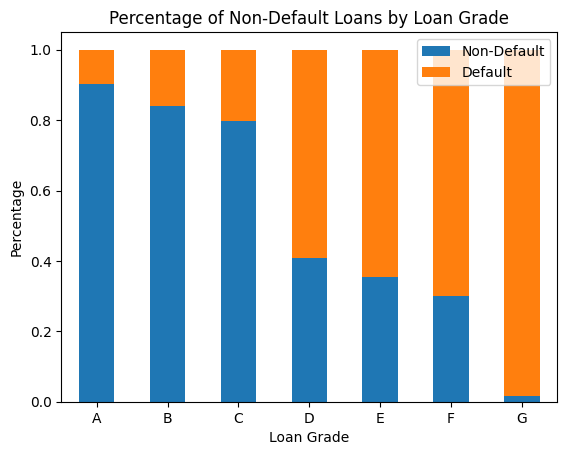

In [33]:
loan_status_loan_grade_counts = df.groupby('loan_grade')['loan_status'].value_counts().unstack()
loan_status_loan_grade_percentages = loan_status_loan_grade_counts.divide(loan_status_loan_grade_counts.sum(axis=1), axis=0)

loan_status_loan_grade_percentages.plot(kind='bar', stacked=True)
plt.legend(['Non-Default', 'Default'])
plt.xlabel('Loan Grade')
plt.ylabel('Percentage')
plt.title('Percentage of Non-Default Loans by Loan Grade')
plt.xticks(rotation=0)
plt.show()

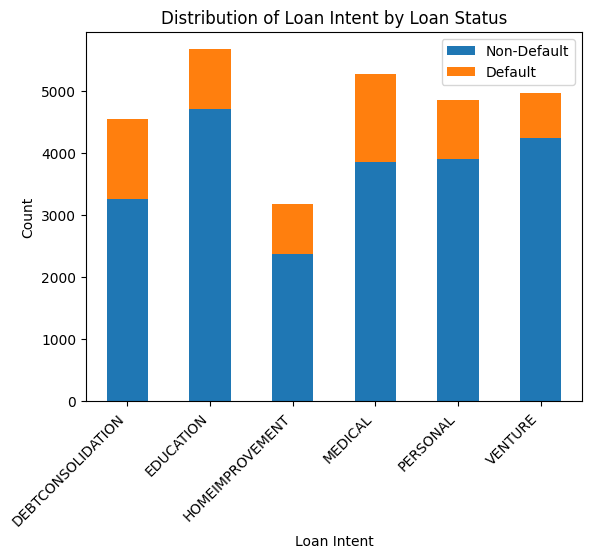

In [34]:
loan_status_loan_intent_counts = df.groupby('loan_intent')['loan_status'].value_counts().unstack()

loan_status_loan_intent_counts.plot(kind='bar', stacked=True)
plt.legend(['Non-Default', 'Default'])
plt.xlabel('Loan Intent')
plt.ylabel('Count')
plt.title('Distribution of Loan Intent by Loan Status')
plt.xticks(rotation=45, ha='right')
plt.show()

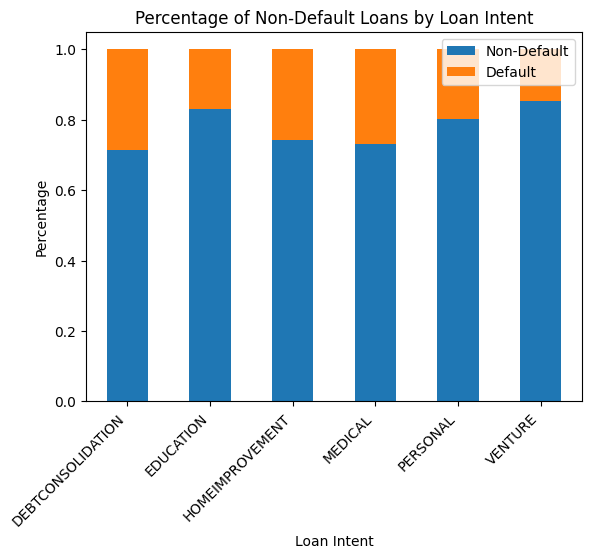

In [35]:
loan_status_loan_intent_counts = df.groupby('loan_intent')['loan_status'].value_counts().unstack()
loan_status_loan_intent_percentages = loan_status_loan_intent_counts.divide(loan_status_loan_intent_counts.sum(axis=1), axis=0)

loan_status_loan_intent_percentages.plot(kind='bar', stacked=True)
plt.legend(['Non-Default', 'Default'])
plt.xlabel('Loan Intent')
plt.ylabel('Percentage')
plt.title('Percentage of Non-Default Loans by Loan Intent')
plt.xticks(rotation=45, ha='right')
plt.show()

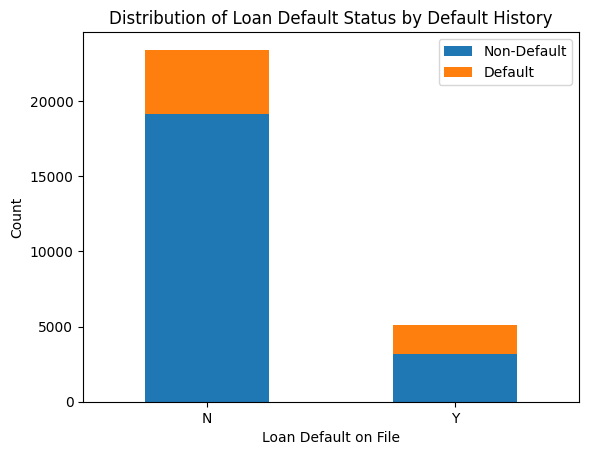

In [36]:
loan_status_chof_counts = df.groupby('cb_person_default_on_file')['loan_status'].value_counts().unstack()

loan_status_chof_counts.plot(kind='bar', stacked=True)
plt.legend(['Non-Default', 'Default'])
plt.xlabel('Loan Default on File')
plt.ylabel('Count')
plt.title('Distribution of Loan Default Status by Default History')
plt.xticks(rotation=0)
plt.show()

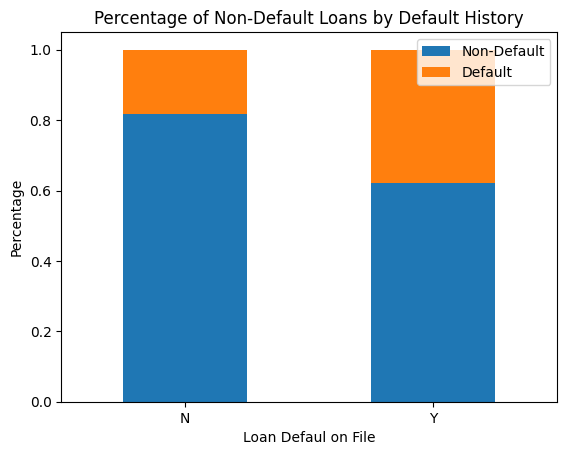

In [37]:
loan_status_chof_counts = df.groupby('cb_person_default_on_file')['loan_status'].value_counts().unstack()
loan_status_chof_percentages = loan_status_chof_counts.divide(loan_status_chof_counts.sum(axis=1), axis=0)

loan_status_chof_percentages.plot(kind='bar', stacked=True)
plt.legend(['Non-Default', 'Default'])
plt.xlabel('Loan Defaul on File')
plt.ylabel('Percentage')
plt.title('Percentage of Non-Default Loans by Default History')
plt.xticks(rotation=0)
plt.show()

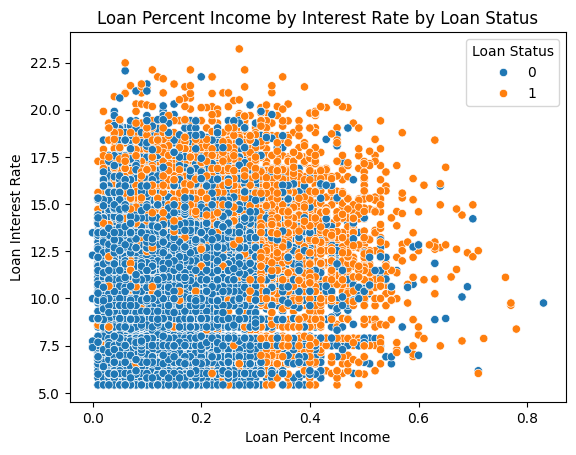

In [38]:
sns.scatterplot(x='loan_percent_income', y='loan_int_rate', hue='loan_status', data=df)
plt.title('Loan Percent Income by Interest Rate by Loan Status')
plt.xlabel('Loan Percent Income')
plt.ylabel('Loan Interest Rate')
plt.legend(title= 'Loan Status')
plt.show()

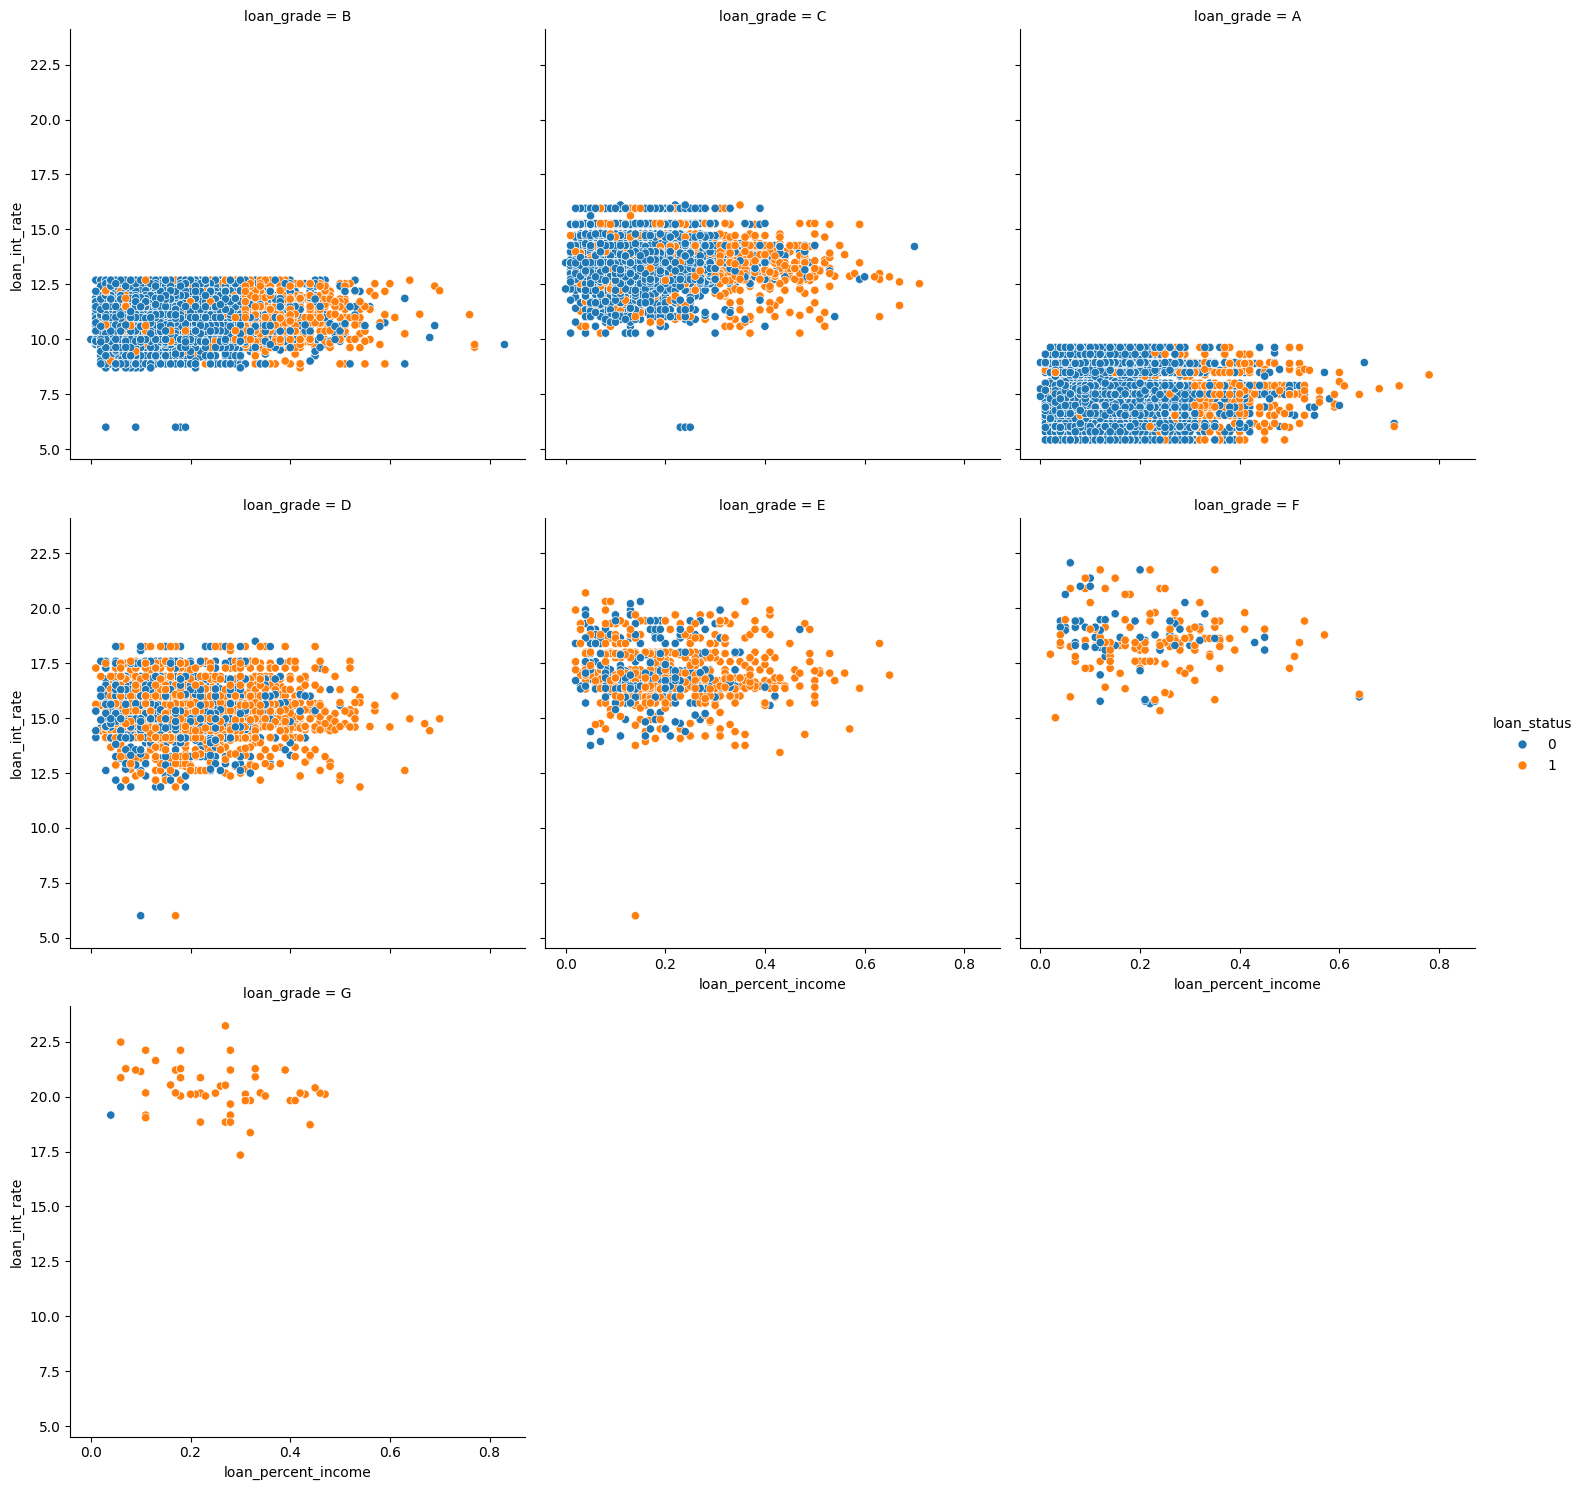

In [39]:
sns.relplot(
    data=df, x="loan_percent_income", y="loan_int_rate",
    hue="loan_status", col="loan_grade",
    kind="scatter", col_wrap=3, alpha=1
)

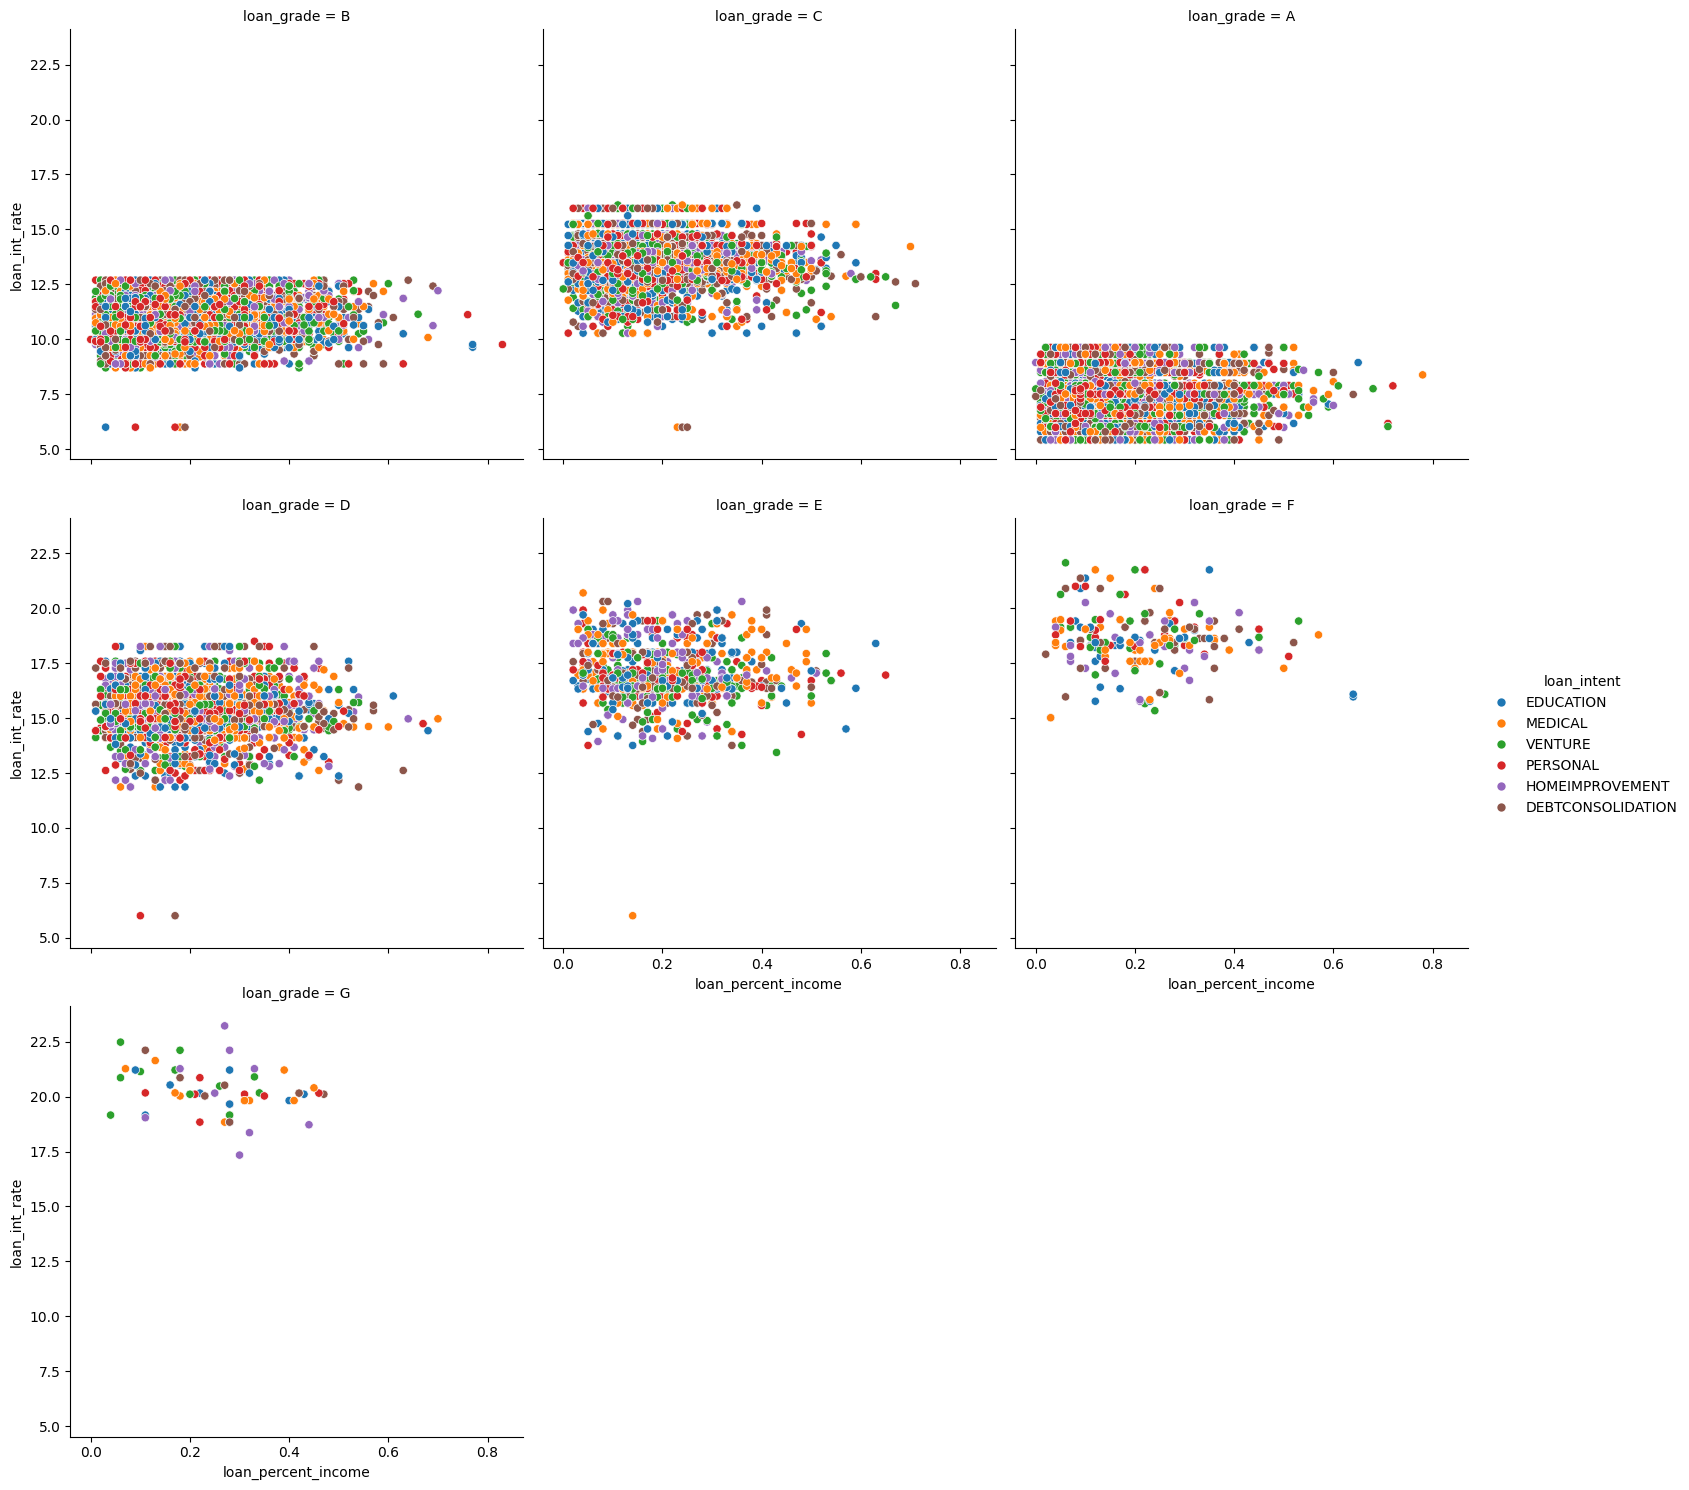

In [40]:
sns.relplot(
    data=df, x="loan_percent_income", y="loan_int_rate",
    hue="loan_intent", col="loan_grade",
    kind="scatter", col_wrap=3, alpha=1)

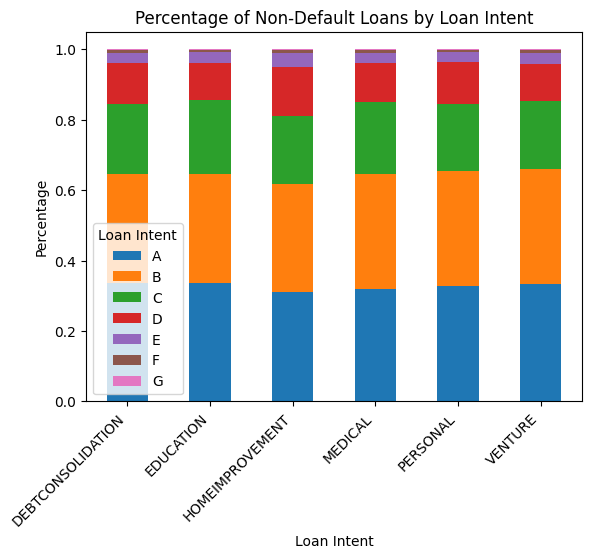

In [41]:
loan_grade_loan_intent_counts = df.groupby('loan_intent')['loan_grade'].value_counts().unstack()
loan_grade_loan_intent_percentages = loan_grade_loan_intent_counts.divide(loan_grade_loan_intent_counts.sum(axis=1), axis=0)

loan_grade_loan_intent_percentages.plot(kind='bar', stacked=True)
plt.legend(title='Loan Intent')
plt.xlabel('Loan Intent')
plt.ylabel('Percentage')
plt.title('Percentage of Non-Default Loans by Loan Intent')
plt.xticks(rotation=45, ha='right')
plt.show()

Most people in the dataset are between 18 and 40 make up to 150 thousand dollars a year, are typically either renters or have mortgages, and most loans are used for Education. The loans typically are typically up to 25,000 dollars, with some reaching 35,000 dollars. Interest rates have a mean of 11% and maximum of 23%. The percent of the loan compared to the income of the borrower (the "Loan Percent Income") has a mean of 17% and typically does not go above 50%, but for some the percent goes up to 83%. Loan Defaults rather common with 20% of loans defaulting. Overall the strongest predictors of defaulting are high interest rates, a high ratio of loan to income, poor loan grade, and having defaulted in the past. The length of credit history, age, and employment length of the borrower are all extreemly week predictors, and do not show any particularly strong correlations. High income and low loan amounts typically are slightly less likely to default, but the correlation is not especially strong. High interest rates and high loan Percent Income both noticeably increase the likelyhood of defaulting. Those who own their homes or have a mortgage are less likely than others to default, well as those who have no record of defaulting in the past. The reason for getting a loan has a small relationship, with those getting personal and venture loans and loans for education being the least likely to default. Poor loan grade dramatically increases the likelihood of default, with most people with grade A loans not defaulting and almost every borrower with a grade G loan defaulting. Graphs were made to compare how the strongly correlating variables impact each other, and found they did not correlate with each other, showing they are independant.
